In [2]:
import numpy as np
import matplotlib.pyplot as plt
from _utils_spline import eval_spline_basis_equispaced_numeric

In [12]:
degree = 3
num_knots = 4
d = np.linspace(0, 1, 1000)
B_full, _, _, knot_list, s = eval_spline_basis_equispaced_numeric(degree, np.min(d), np.max(d), num_knots, d).values()

In [13]:
B_full.shape

(1000, 8)

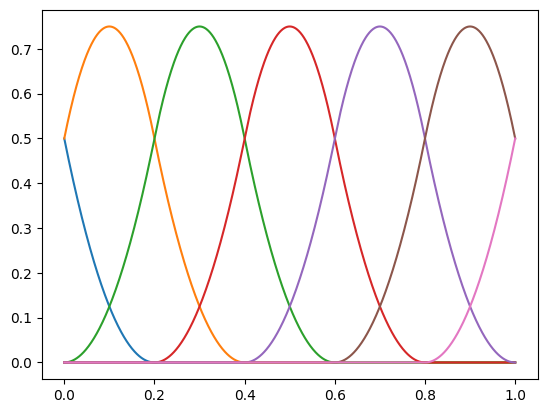

In [10]:
plt.plot(d, B_full)

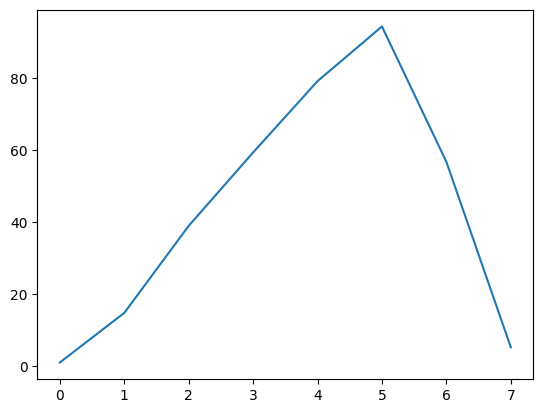

In [34]:
plt.plot((B_full.T@B_full)@w1)

In [39]:
l = (np.arange(B_full.shape[0])-B_full.shape[0]/2)/B_full.shape[0]
w = np.linalg.inv(B_full.T@B_full)@B_full.T@l

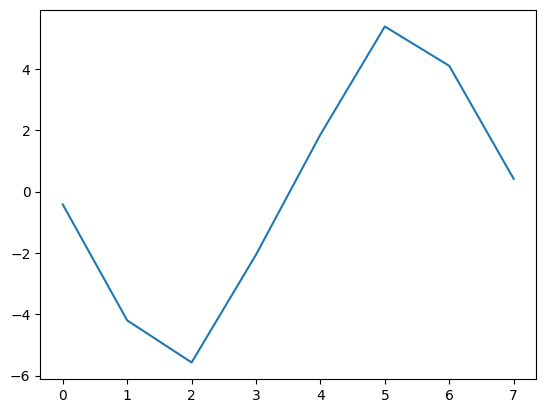

In [41]:
plt.plot(B_full.T@l)

In [36]:
w

array([-0.698, -0.5  , -0.302, -0.104,  0.094,  0.292,  0.49 ,  0.688])

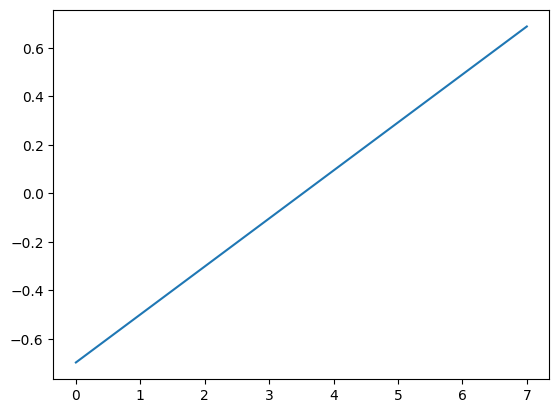

In [37]:
plt.plot(w)

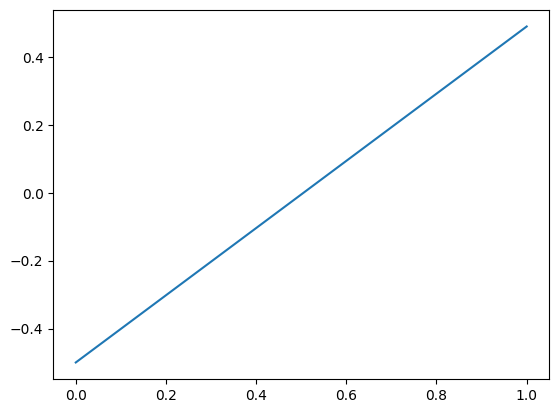

In [38]:
plt.plot(d, B_full@w)

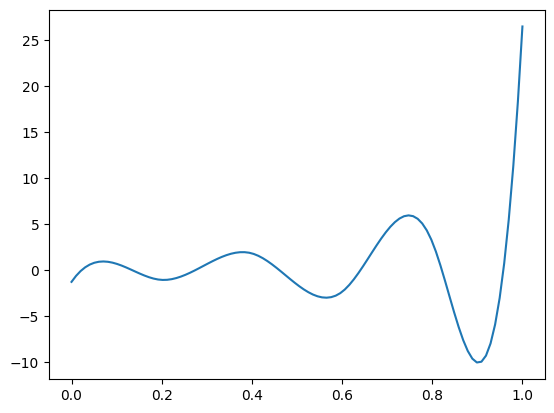

In [44]:
plt.plot(d, B_full@np.linalg.inv(B_full.T@B_full)@w1)

In [3]:
s

{'x': x,
 'full_knots': array([-0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25]),
 'interior_knots': array([0.25, 0.5 , 0.75]),
 'basis': [[Piecewise((1, (x >= -0.25) & (x < 0)), (0, True)),
   Piecewise((1, (x < 0.25) & (x >= 0)), (0, True)),
   Piecewise((1, (x >= 0.25) & (x < 0.5)), (0, True)),
   Piecewise((1, (x >= 0.5) & (x < 0.75)), (0, True)),
   Piecewise((1, (x >= 0.75) & (x < 1.0)), (0, True)),
   Piecewise((1, (x >= 1.0) & (x <= 1.25)), (0, True))],
  [(1.0 - 4.0*x)*Piecewise((1, (x < 0.25) & (x >= 0)), (0, True)) + (4.0*x + 1.0)*Piecewise((1, (x >= -0.25) & (x < 0)), (0, True)),
   4.0*x*Piecewise((1, (x < 0.25) & (x >= 0)), (0, True)) + (2.0 - 4.0*x)*Piecewise((1, (x >= 0.25) & (x < 0.5)), (0, True)),
   (3.0 - 4.0*x)*Piecewise((1, (x >= 0.5) & (x < 0.75)), (0, True)) + (4.0*x - 1.0)*Piecewise((1, (x >= 0.25) & (x < 0.5)), (0, True)),
   (4.0 - 4.0*x)*Piecewise((1, (x >= 0.75) & (x < 1.0)), (0, True)) + (4.0*x - 2.0)*Piecewise((1, (x >= 0.5) & (x < 0.75)), (0, True)),
   

In [47]:
eval_spline_basis_equispaced_numeric(degree, np.min(d), np.max(d), num_knots, d)

{'B': array([[1.        , 0.        , 0.        , 0.        , 0.        ],
        [0.95959596, 0.04040404, 0.        , 0.        , 0.        ],
        [0.91919192, 0.08080808, 0.        , 0.        , 0.        ],
        [0.87878788, 0.12121212, 0.        , 0.        , 0.        ],
        [0.83838384, 0.16161616, 0.        , 0.        , 0.        ],
        [0.7979798 , 0.2020202 , 0.        , 0.        , 0.        ],
        [0.75757576, 0.24242424, 0.        , 0.        , 0.        ],
        [0.71717172, 0.28282828, 0.        , 0.        , 0.        ],
        [0.67676768, 0.32323232, 0.        , 0.        , 0.        ],
        [0.63636364, 0.36363636, 0.        , 0.        , 0.        ],
        [0.5959596 , 0.4040404 , 0.        , 0.        , 0.        ],
        [0.55555556, 0.44444444, 0.        , 0.        , 0.        ],
        [0.51515152, 0.48484848, 0.        , 0.        , 0.        ],
        [0.47474747, 0.52525253, 0.        , 0.        , 0.        ],
        [0.4343

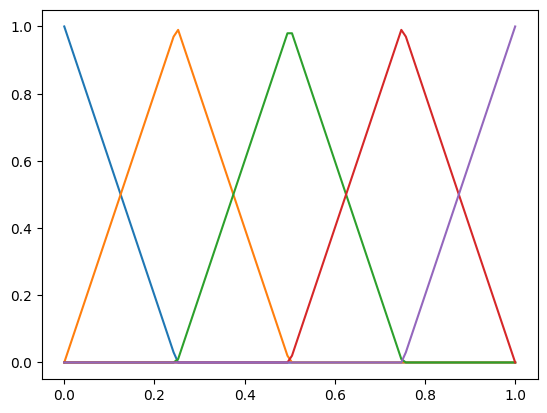

In [44]:
plt.plot(d, B_full)
plt.show()

0
1
2


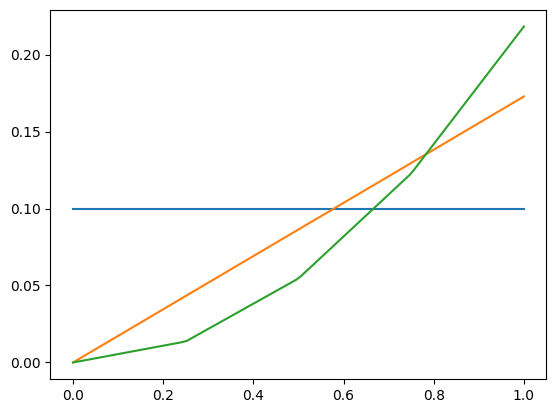

In [45]:
c = 2
B_w = np.zeros((B_full.shape[0], degree+c))
for k in range(degree+c):
    print(k)
    w_k = (np.arange(B_full.shape[1]))**k
    B_w[:, k] = B_full @ w_k
    B_w[:, k] /= np.dot(B_w[:, k], B_w[:, k])**0.5
    # for l in range(k):
        # print(k, l)
        # B_w[:, k] -= np.dot(B_w[:, k], B_w[:, l])*B_w[:, l]

plt.plot(d, B_w)
 #plt.legend()
plt.show()

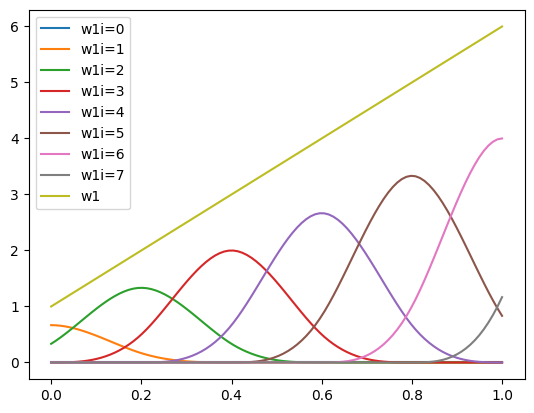

In [33]:
w0 = np.arange(B_full.shape[1])**0
w1 = np.arange(B_full.shape[1])**1
w2 = np.arange(B_full.shape[1])**2
for i, w1i in enumerate(w1):
    plt.plot(d, B_full[:, i] * w1i, label=f'w1i={w1i}')
#plt.plot(d, B_full @ w0, label='w0')
plt.plot(d, B_full @ w1, label='w1')
#plt.plot(d, B_full @ w2, label='w2')
plt.legend()
plt.show()

In [28]:
l0 = np.ones(B_full.shape[0])
print('Design matrix product with constant curve: ', f'{np.round(B_full.T @ l0, 2)}')

l1 = np.linspace(0, 1, B_full.shape[0])-0.5
print('Design matrix product with linear curve: ', f'{np.round(B_full.T @ l1, 2)}')

Design matrix product with constant curve:  [0.46 4.83 8.7  9.   9.   9.   9.   9.   9.   9.   9.   8.7  4.83 0.46]
Design matrix product with linear curve:  [-0.22 -2.23 -3.53 -2.86 -2.05 -1.23 -0.41  0.41  1.23  2.05  2.86  3.53
  2.23  0.22]
